# Week 4 Prep: Virtual O-RU Power Simulation

## Objective
We have measured the power consumption of a generic compute platform (Laptop/Mini-PC) acting as a traffic sink. We found it to be highly efficient (low idle power, low active power).

However, a real **O-RAN Radio Unit (O-RU)** behaves differently. It has:
1.  **High Static Power:** Due to FPGA/ASIC leakage and constant RF biasing.
2.  **Load-Dependent Scaling:** The Power Amplifier (PA) consumes energy proportional to the RF signal amplitude (traffic load), but with non-linear efficiency.

**Goal:** This notebook simulates what our Week 3 experiment *would* have looked like if we were measuring a real O-RU, allowing us to perform a "Gap Analysis" between our software measurements and hardware reality.

## The Gap Analysis
| Characteristic | Our Measurement (Laptop) | Real O-RU (Simulation) |
| :--- | :--- | :--- |
| **Idle Power** | Very Low (~2-4W) | High (30-50% of Max) |
| **Scaling** | Flat (mostly C-states) | Linear/Steep (PA draw) |
| **Response** | Discrete (Step function) | Analog (Follows traffic) |

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Setup plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [12, 6]

## 1. Define the O-RU Power Model

We will use a standard linear approximation for O-RU power consumption, often cited in energy efficiency research (e.g., standard ETSI or WINLAB models).

$$ P_{RU}(L) = P_{static} + \Delta_P \cdot L $$

Where:
- $P_{RU}$: Total Power
- $P_{static}$: Power consumed at 0% load (Bias circuits, FPGA static, cooling)
- $\Delta_P$: The dynamic range (Max Power - Static Power)
- $L$: Traffic Load (0.0 to 1.0)

**Citation-backed anchor (Digital Twin for Network Energy Consumption, `P12.pdf`):**
- Macro RU: $P_{min}=197$ W, $P_{max}=531$ W (static ratio $pprox 0.371$)
- Micro RU: $P_{min}=59$ W, $P_{max}=110$ W (static ratio $pprox 0.536$)

We keep a linear model for Week 4 (shape is the focus); exact parameters are scenario- and hardware-dependent.

In [9]:
def simulate_oru_power(load_percent, max_power_w=300, static_ratio=0.4):
    """
    Calculates theoretical O-RU power based on load.
    
    Args:
        load_percent (float): Traffic load (0.0 to 100.0)
        max_power_w (float): Maximum rated power of the RU
        static_ratio (float): Fraction of max power consumed at idle (0.0 to 1.0)
        
    Returns:
        float: Estimated power in Watts
    """
    p_static = max_power_w * static_ratio
    p_dynamic_max = max_power_w - p_static
    
    # Create a mask for valid load
    load_fraction = np.clip(load_percent / 100.0, 0, 1) 
    
    return p_static + (p_dynamic_max * load_fraction)

## 2. Load Your Experimental Data
yes, We will load the `power_uw.txt` from your Jan 23 run. Then we will parse your marker log (`markers.csv`, which contains the console output of the sweep script) to reconstruct the traffic profile **aligned to timestamps**.

In [10]:
from pathlib import Path
import re
from datetime import datetime

repo_root = Path.cwd().resolve().parent  # notebooks/ -> repo root
run_dir = repo_root / 'runs' / '2026-01-23'
power_path = run_dir / 'power_uw.txt'
markers_log_path = run_dir / 'markers.csv'

def parse_utc(ts: str) -> datetime:
    return datetime.strptime(ts, '%Y-%m-%dT%H:%M:%SZ')

def load_power_uw(path: Path):
    iso_re = re.compile(r'(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}Z)\s+(\d+)')
    if not path.exists():
        return None
    timestamps = []
    watts = []
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            m = iso_re.search(line)
            if not m:
                continue
            timestamps.append(parse_utc(m.group(1)))
            watts.append(float(m.group(2)) / 1_000_000)  # uW -> W
    if not timestamps:
        return None
    df_local = pd.DataFrame({'timestamp': timestamps, 'watts_measured': watts})
    start_time = df_local['timestamp'].iloc[0]
    df_local['time_rel'] = (df_local['timestamp'] - start_time).dt.total_seconds()
    return df_local

def load_marker_events(path: Path):
    # The run artifact is a console log that contains marker lines like:
    # [2026-01-23T09:39:05Z] MARKER: Start_Load_L_Run1
    marker_re = re.compile(r'\[(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}Z)\]\s+MARKER:\s+([A-Za-z0-9_]+)')
    if not path.exists():
        return None
    events = []
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            m = marker_re.search(line)
            if not m:
                continue
            events.append((parse_utc(m.group(1)), m.group(2)))
    if not events:
        return None
    return pd.DataFrame(events, columns=['timestamp', 'marker']).sort_values('timestamp')

def build_intervals(events_df: pd.DataFrame):
    open_starts = {}
    intervals = []
    for ts, marker in events_df[['timestamp', 'marker']].itertuples(index=False):
        if marker.startswith('Start_'):
            open_starts[marker[len('Start_'):]] = ts
            continue
        if marker.startswith('Stop_'):
            key = marker[len('Stop_'):]
            start_ts = open_starts.pop(key, None)
            if start_ts is None:
                continue
            if ts >= start_ts:
                intervals.append((start_ts, ts, key))
    return intervals

def key_to_load_percent(key: str) -> float:
    if 'Load_L' in key:
        return 30.0
    if 'Load_M' in key:
        return 60.0
    if 'Load_H' in key:
        return 100.0
    return 0.0

df = load_power_uw(power_path)
if df is None:
    print('Power file not found or could not be parsed. Generating dummy timeline for demo.')
    time_steps = np.arange(0, 400, 1)
    traffic_load = np.zeros_like(time_steps, dtype=float)
    traffic_load[(time_steps > 60) & (time_steps < 120)] = 30.0
    traffic_load[(time_steps > 150) & (time_steps < 210)] = 60.0
    traffic_load[(time_steps > 240) & (time_steps < 300)] = 100.0
    df = pd.DataFrame({'time_rel': time_steps, 'load_percent': traffic_load})
    df['watts_measured'] = 2.0
    df.loc[df['load_percent'] > 0, 'watts_measured'] = 8.0
else:
    print(f'Loaded {len(df)} power samples from: {power_path}')
    df['load_percent'] = 0.0
    events_df = load_marker_events(markers_log_path)
    if events_df is None:
        print(f'No markers found at {markers_log_path}; leaving load_percent=0 for entire run.')
    else:
        intervals = build_intervals(events_df)
        print(f'Parsed {len(intervals)} start/stop intervals from marker log.')
        for start_ts, stop_ts, key in intervals:
            pct = key_to_load_percent(key)
            if pct <= 0:
                continue
            df.loc[(df['timestamp'] >= start_ts) & (df['timestamp'] <= stop_ts), 'load_percent'] = pct

# Apply the Virtual O-RU model to the aligned traffic profile
# Citation-backed anchor parameters from P12 (Macro RU in highway scenario)
P12_MACRO_PMIN_W = 197
P12_MACRO_PMAX_W = 531
P12_MACRO_STATIC_RATIO = P12_MACRO_PMIN_W / P12_MACRO_PMAX_W
df['watts_oru_sim'] = simulate_oru_power(df['load_percent'], max_power_w=P12_MACRO_PMAX_W, static_ratio=P12_MACRO_STATIC_RATIO)
df['efficiency_gap'] = np.where(df['watts_measured'] > 0, df['watts_oru_sim'] / df['watts_measured'], np.nan)

Loaded 2571 power samples from: C:\Users\USER\Documents\VSCode\TEEP Probation\runs\2026-01-23\power_uw.txt
Parsed 10 start/stop intervals from marker log.


## 3. Parameter Sensitivity (Make the Gap Reviewer-Proof)

The exact O-RU parameters ($P_{max}$ and $P_{static}$ ratio) vary by RU class (macro vs small cell), vendor, and band. To avoid over-claiming, we do a small sensitivity sweep and show that the **conclusion is robust**: even the *lowest plausible* static power dominates the proxy platform power.

We keep the *shape* linear here (Week 4 scope), and treat non-linear PA efficiency as a future refinement.

In [11]:
# Sensitivity sweep for RU parameters
sweep = pd.DataFrame(
    [
        # (label, Pmax_W, static_ratio)
        ('P12 Macro RU (anchor)', 531, 197/531),
        ('P12 Micro RU (anchor)', 110, 59/110),
        ('Macro (low static)', 300, 0.30),
        ('Macro (baseline)',   300, 0.40),
        ('Macro (high static)',300, 0.50),
        ('Smaller RU',         200, 0.40),
        ('Larger RU',          400, 0.40),
    ],
    columns=['scenario', 'pmax_w', 'static_ratio']
 )
sweep['pstatic_w'] = sweep['pmax_w'] * sweep['static_ratio']
sweep['pdyn_w'] = sweep['pmax_w'] - sweep['pstatic_w']
sweep

,scenario,pmax_w,static_ratio,pstatic_w,pdyn_w
0,P12 Macro RU (anchor),531,0.370998,197.0,334.0
1,P12 Micro RU (anchor),110,0.536364,59.0,51.0
2,Macro (low static),300,0.300000,90.0,210.0
3,Macro (baseline),300,0.400000,120.0,180.0
4,Macro (high static),300,0.500000,150.0,150.0
5,Smaller RU,200,0.400000,80.0,120.0
6,Larger RU,400,0.400000,160.0,240.0


In [14]:
# Compute RU power bands over the actual timeline (min/max across scenarios)
from datetime import timedelta

sim_cols = []
for _, row in sweep.iterrows():
    col = f"oru_{int(row['pmax_w'])}W_sr{int(row['static_ratio']*100)}"
    df[col] = simulate_oru_power(df['load_percent'], max_power_w=row['pmax_w'], static_ratio=row['static_ratio'])
    sim_cols.append(col)

df['watts_oru_min'] = df[sim_cols].min(axis=1)
df['watts_oru_max'] = df[sim_cols].max(axis=1)

# Reviewer-safe summary: compute proxy stats only inside the experiment window and trim boundaries
trim_s = 10

def _median(series: pd.Series) -> float:
    if series is None or series.empty:
        return float('nan')
    return float(series.median())

def _mean(series: pd.Series) -> float:
    if series is None or series.empty:
        return float('nan')
    return float(series.mean())

summary_rows = []

if 'timestamp' in df.columns and 'intervals' in globals() and intervals:
    exp_start = min(s for s, _, _ in intervals)
    exp_end = max(e for _, e, _ in intervals)
    in_window = (df['timestamp'] >= exp_start) & (df['timestamp'] <= exp_end)

    load_intervals = [(s, e, k) for (s, e, k) in intervals if 'Load_' in k]
    active_mask = pd.Series(False, index=df.index)
    boundary_near_load = pd.Series(False, index=df.index)

    for s, e, _k in load_intervals:
        # Active scoring window: trim start/end of each load segment
        s2 = s + timedelta(seconds=trim_s)
        e2 = e - timedelta(seconds=trim_s)
        if s2 < e2:
            active_mask |= (df['timestamp'] >= s2) & (df['timestamp'] <= e2)

        # Exclude boundary-adjacent regions from idle scoring
        boundary_near_load |= ((df['timestamp'] >= (s - timedelta(seconds=trim_s))) & (df['timestamp'] <= (s + timedelta(seconds=trim_s))))
        boundary_near_load |= ((df['timestamp'] >= (e - timedelta(seconds=trim_s))) & (df['timestamp'] <= (e + timedelta(seconds=trim_s))))

    safe_idle_mask = in_window & (df['load_percent'] == 0) & (~boundary_near_load)
    safe_active_mask = in_window & active_mask

    # Proxy stats
    proxy_idle_med = _median(df.loc[safe_idle_mask, 'watts_measured'])
    proxy_active_med = _median(df.loc[safe_active_mask, 'watts_measured'])

    summary_rows.append(('proxy_idle_median_w (trimmed)', proxy_idle_med))
    summary_rows.append(('proxy_active_median_w (trimmed)', proxy_active_med))

    # Per-load medians (trimmed)
    for pct in (30.0, 60.0, 100.0):
        mask = safe_active_mask & (df['load_percent'] == pct)
        summary_rows.append((f'proxy_load_{int(pct)}pct_median_w (trimmed)', _median(df.loc[mask, 'watts_measured'])))

    # RU model bands (over same windows)
    # Also record the citation-backed anchors explicitly (P12 highway digital twin)
    P12_MACRO_PMIN_W = 197
    P12_MACRO_PMAX_W = 531
    P12_MICRO_PMIN_W = 59
    P12_MICRO_PMAX_W = 110
    summary_rows.append(('P12_macro_pmin_w', float(P12_MACRO_PMIN_W)))
    summary_rows.append(('P12_macro_pmax_w', float(P12_MACRO_PMAX_W)))
    summary_rows.append(('P12_macro_static_ratio', float(P12_MACRO_PMIN_W / P12_MACRO_PMAX_W)))
    summary_rows.append(('P12_macro_delta_w (pmax-pmin)', float(P12_MACRO_PMAX_W - P12_MACRO_PMIN_W)))
    summary_rows.append(('P12_micro_pmin_w', float(P12_MICRO_PMIN_W)))
    summary_rows.append(('P12_micro_pmax_w', float(P12_MICRO_PMAX_W)))
    summary_rows.append(('P12_micro_static_ratio', float(P12_MICRO_PMIN_W / P12_MICRO_PMAX_W)))
    summary_rows.append(('P12_micro_delta_w (pmax-pmin)', float(P12_MICRO_PMAX_W - P12_MICRO_PMIN_W)))

    summary_rows.append(('oru_idle_min_w (from sweep)', float(sweep['pstatic_w'].min())))
    summary_rows.append(('oru_idle_max_w (from sweep)', float(sweep['pstatic_w'].max())))
    summary_rows.append(('oru_peak_min_w (from sweep)', float(sweep['pmax_w'].min())))
    summary_rows.append(('oru_peak_max_w (from sweep)', float(sweep['pmax_w'].max())))

    # Gap ratios (use medians so spikes don’t dominate)
    if proxy_idle_med and not np.isnan(proxy_idle_med) and proxy_idle_med > 0:
        summary_rows.append(('gap_idle_min_ratio (oru_static_min / proxy_idle)', float(sweep['pstatic_w'].min() / proxy_idle_med)))
    if proxy_active_med and not np.isnan(proxy_active_med) and proxy_active_med > 0:
        summary_rows.append(('gap_active_min_ratio (oru_static_min / proxy_active)', float(sweep['pstatic_w'].min() / proxy_active_med)))

    # Optional: write a small markdown summary next to the plots for easy linking
    output_dir = r"../assets/2026-01-26/plots"
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    summary_path = os.path.join(output_dir, "gap_analysis_sensitivity_summary.md")
    with open(summary_path, 'w', encoding='utf-8') as f:
        f.write('# Gap Analysis Sensitivity Summary (Trimmed Windows)\n\n')
        f.write(f'- Trim policy: {trim_s}s removed at start/end of each load segment; idle excludes ±{trim_s}s around load boundaries.\n')
        f.write(f'- Experiment window: {exp_start.isoformat()} → {exp_end.isoformat()}\n\n')
        f.write('## Key Numbers\n\n')
        for k, v in summary_rows:
            f.write(f'- **{k}**: {v:.3f}\n')
    print(f"Wrote summary to: {summary_path}")
else:
    # Fallback for synthetic timeline (no timestamps/markers)
    summary_rows.append(('oru_idle_min_w (from sweep)', float(sweep['pstatic_w'].min())))
    summary_rows.append(('oru_idle_max_w (from sweep)', float(sweep['pstatic_w'].max())))
    summary_rows.append(('oru_peak_min_w (from sweep)', float(sweep['pmax_w'].min())))
    summary_rows.append(('oru_peak_max_w (from sweep)', float(sweep['pmax_w'].max())))

pd.DataFrame(summary_rows, columns=['metric', 'value'])

Wrote summary to: ../assets/2026-01-26/plots\gap_analysis_sensitivity_summary.md


,metric,value
0,proxy_idle_median_w (trimmed),3.946510
1,proxy_active_median_w (trimmed),3.946510
2,proxy_load_30pct_median_w (trimmed),3.946510
3,proxy_load_60pct_median_w (trimmed),3.946510
4,proxy_load_100pct_median_w (trimmed),14.651107
5,P12_macro_pmin_w,197.000000
6,P12_macro_pmax_w,531.000000
7,P12_macro_static_ratio,0.370998
8,P12_macro_delta_w (pmax-pmin),334.000000
9,P12_micro_pmin_w,59.000000


Sensitivity plot saved to: ../assets/2026-01-26/plots\gap_analysis_sensitivity.png


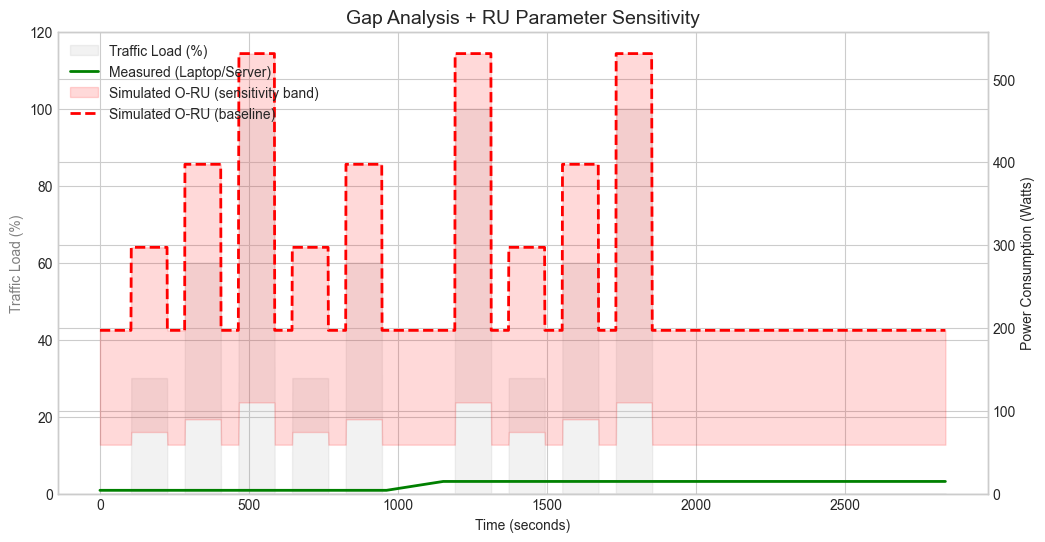

In [13]:
# Plot: same gap analysis but with a sensitivity band for the RU model
# (Robustness) If cells were run out-of-order, ensure the min/max band columns exist.
if 'watts_oru_min' not in df.columns or 'watts_oru_max' not in df.columns:
    scenario_cols = []
    for _i, row in sweep.iterrows():
        col = f"oru_{int(row['pmax_w'])}W_sr{int(round(float(row['static_ratio']) * 100))}"
        df[col] = simulate_oru_power(df['load_percent'], max_power_w=float(row['pmax_w']), static_ratio=float(row['static_ratio']))
        scenario_cols.append(col)
    df['watts_oru_min'] = df[scenario_cols].min(axis=1)
    df['watts_oru_max'] = df[scenario_cols].max(axis=1)

fig2, ax1b = plt.subplots()

ax1b.fill_between(df['time_rel'], df['load_percent'], color='gray', alpha=0.1, label='Traffic Load (%)')
ax1b.set_ylabel('Traffic Load (%)', color='gray')
ax1b.set_ylim(0, 120)

ax2b = ax1b.twinx()
ax2b.plot(df['time_rel'], df['watts_measured'], label='Measured (Laptop/Server)', color='green', linewidth=2)

# RU band (min/max)
ax2b.fill_between(
    df['time_rel'],
    df['watts_oru_min'],
    df['watts_oru_max'],
    color='red',
    alpha=0.15,
    label='Simulated O-RU (sensitivity band)',
 )

# Baseline RU line (the one used in the main plot)
ax2b.plot(df['time_rel'], df['watts_oru_sim'], label='Simulated O-RU (baseline)', color='red', linestyle='--', linewidth=2)

ax2b.set_ylabel('Power Consumption (Watts)')
ax2b.set_ylim(0, max(350, float(df['watts_oru_max'].max()) * 1.05))

plt.title('Gap Analysis + RU Parameter Sensitivity', fontsize=14)
ax1b.set_xlabel('Time (seconds)')

lines1, labels1 = ax1b.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2b.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.grid(True)

output_dir = r"../assets/2026-01-26/plots"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
output_path2 = os.path.join(output_dir, "gap_analysis_sensitivity.png")
plt.savefig(output_path2, dpi=300, bbox_inches='tight')
print(f"Sensitivity plot saved to: {output_path2}")

plt.show()

## 4. Visualize the Disparity (The "Gap Analysis")
This plot is the key deliverable for tomorrow. It shows the fundamental difference between General Purpose Compute (your laptop) and Radio Hardware.

Plot saved to: ../assets/2026-01-26/plots\gap_analysis_simulation.png


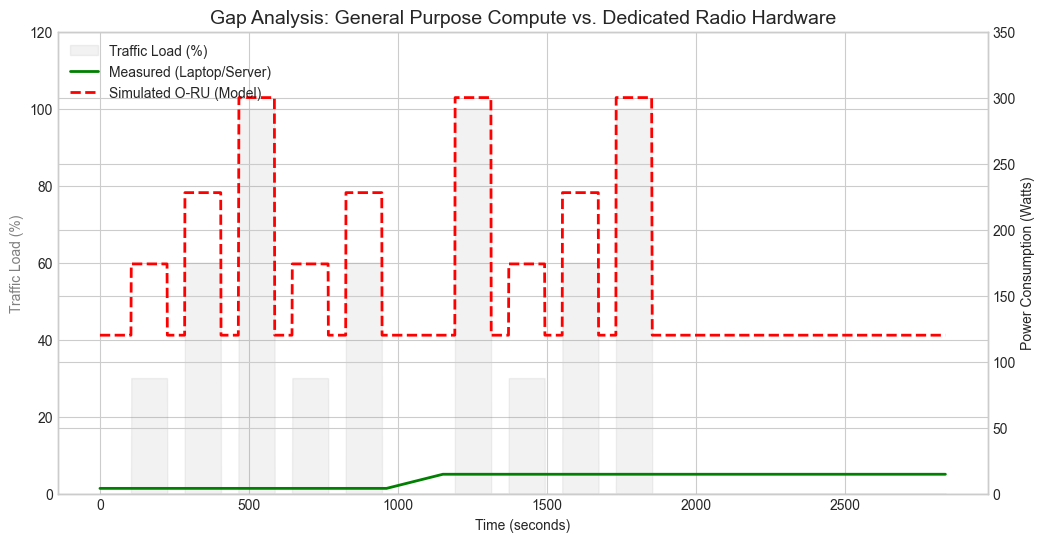

In [10]:
fig, ax1 = plt.subplots()

# Plot 1: The Traffic Load (Background)
ax1.fill_between(df['time_rel'], df['load_percent'], color='gray', alpha=0.1, label='Traffic Load (%)')
ax1.set_ylabel('Traffic Load (%)', color='gray')
ax1.set_ylim(0, 120)

# Create twin axis for Power
ax2 = ax1.twinx()

# Plot 2: Real Measured Power (The Laptop)
ax2.plot(df['time_rel'], df['watts_measured'], label='Measured (Laptop/Server)', color='green', linewidth=2)

# Plot 3: Simulated O-RU Power
ax2.plot(df['time_rel'], df['watts_oru_sim'], label='Simulated O-RU (Model)', color='red', linestyle='--', linewidth=2)

ax2.set_ylabel('Power Consumption (Watts)')
ax2.set_ylim(0, 350)

# Labels and Title
plt.title('Gap Analysis: General Purpose Compute vs. Dedicated Radio Hardware', fontsize=14)
ax1.set_xlabel('Time (seconds)')

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.grid(True)

# Define output path
output_dir = r"../assets/2026-01-26/plots"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
output_path = os.path.join(output_dir, "gap_analysis_simulation.png")

plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"Plot saved to: {output_path}")

plt.show()

## 5. Next Steps for Week 4
1. Replace placeholder RU parameters ($P_{max}$ and $P_{static}$ ratio) with a cited range (WINLAB/ETSI/vendor datasheet).
2. Validate outliers: flag power spikes not aligned to marker intervals.
3. Optional: refine $P_{RU}(L)$ to a non-linear PA efficiency curve once RU reference data is selected.

## 6. Scan existing PDFs for RU/BS power model data

Before searching new papers, we scan the PDFs already stored in `assets/` for keywords that typically appear in RU/base-station power models (e.g., **P0**, **Δp/Delta**, **static power**, **load dependence**, **power consumption**).

Output: a short markdown report listing which PDFs have likely-relevant matches and which pages to open first.

In [4]:
from __future__ import annotations

import re
from dataclasses import dataclass
from pathlib import Path
from typing import List, Optional, Tuple


def find_repo_root(start: Path) -> Path:
    """Walk upwards until we find an `assets/` directory (repo root heuristic)."""
    start = start.resolve()
    candidates = [start, *start.parents]
    for p in candidates:
        if (p / "assets").exists():
            return p
    # Fallback: if running in an unexpected CWD, just use start
    return start


# --- Workspace paths ---
WORKSPACE = find_repo_root(Path.cwd())
ASSETS_DIR = WORKSPACE / "assets"

# --- Keyword patterns (case-insensitive) ---
KW_PATTERNS = [
    r"\bP0\b",
    r"\bP_?0\b",
    r"\bPmax\b",
    r"\bP\s*max\b",
    r"\bPout\b",
    r"\bDelta\b",
    r"\bΔ\b",
    r"\bstatic\b",
    r"\bidle\b",
    r"\bsleep\b",
    r"power\s+consumption",
    r"consumed\s+power",
    r"load\s+depend",
    r"energy\s+efficien",
    r"base\s+station",
    r"radio\s+unit",
    r"O-?RU\b",
    r"O-?RAN\b",
    r"EARTH\b",
    r"ETSI\b",
    r"\b5G\b",
    r"\bLTE\b",
    r"\bmacro\b",
    r"\bmicro\b",
    r"\bpico\b",
    r"\bsmall\s+cell\b",
    r"efficiency\s+gap",
    r"watts?",
    r"\bW\b",
    r"kW",
    r"\bAC\b",
    r"\bDC\b",
    r"\bPA\b",
    r"power\s+amplifier",
    r"fronthaul",
    r"\bCPRI\b",
    r"\beCPRI\b",
    r"\bRU\b",
    r"\bRRU\b",
    r"\bAAU\b",
    r"\bRAN\b",
    r"\bMIMO\b",
    r"\bMassive\s+MIMO\b",
    r"\bTRX\b",
    r"\bTRx\b",
    r"\bTDD\b",
    r"\bFDD\b",
    r"\bBW\b",
    r"bandwidth",
    r"carrier",
    r"\bMHz\b",
    r"\bGHz\b",
    r"\bmodel\b",
    r"\blinear\b",
    r"P\s*=\s*P0\s*\+",
    r"P\s*=\s*P_?0\s*\+",
    r"\bΔp\b",
    r"\bdelta\s*p\b",
    r"\bA\b\s*\(.*\)\s*\+\s*B\b",
    r"\baffine\b",
    r"\bintercept\b",
    r"\bslope\b",
    r"\bTable\b",
    r"\bFig(ure)?\.?\b",
    r"\bmeasurement\s+point\b",
    r"\binput\s+power\b",
    r"\boutput\s+power\b",
    r"\btraffic\s+load\b",
    r"\butilization\b",
    r"\bPRB\b",
    r"\bRB\b",
    r"resource\s+block",
    r"\bthroughput\b",
    r"\bGbps\b",
    r"\bMbps\b",
]
KW_RE = re.compile("|".join(f"(?:{p})" for p in KW_PATTERNS), flags=re.IGNORECASE)


@dataclass(frozen=True)
class PdfHit:
    pdf_path: Path
    page_index: int
    matched_text: str
    match_snippet: str


def _safe_snippet(text: str, match_span: Tuple[int, int], radius: int = 120) -> str:
    start = max(0, match_span[0] - radius)
    end = min(len(text), match_span[1] + radius)
    snippet = text[start:end].replace("\n", " ").strip()
    snippet = re.sub(r"\s+", " ", snippet)
    return snippet


def find_pdfs(root: Path) -> List[Path]:
    return sorted(root.rglob("*.pdf"))


def try_extract_text_pypdf(pdf_path: Path, max_pages: Optional[int] = None) -> List[str]:
    """Best-effort text extraction. Returns one string per page."""
    from pypdf import PdfReader  # type: ignore

    reader = PdfReader(str(pdf_path))
    pages = reader.pages
    if max_pages is not None:
        pages = pages[:max_pages]
    out: List[str] = []
    for p in pages:
        try:
            out.append(p.extract_text() or "")
        except Exception:
            out.append("")
    return out


def scan_pdf_for_keywords(pdf_path: Path, max_pages: Optional[int] = None) -> List[PdfHit]:
    pages_text = try_extract_text_pypdf(pdf_path, max_pages=max_pages)
    hits: List[PdfHit] = []
    for i, text in enumerate(pages_text):
        if not text:
            continue
        m = KW_RE.search(text)
        if not m:
            continue
        hits.append(
            PdfHit(
                pdf_path=pdf_path,
                page_index=i,
                matched_text=m.group(0),
                match_snippet=_safe_snippet(text, m.span()),
            )
        )
    return hits


def scan_assets_pdfs(
    assets_dir: Path,
    max_pages_per_pdf: Optional[int] = 20,
    top_n_hits: int = 50,
) -> List[PdfHit]:
    pdfs = find_pdfs(assets_dir)
    if not pdfs:
        raise FileNotFoundError(f"No PDFs found under {assets_dir}")

    all_hits: List[PdfHit] = []
    for pdf in pdfs:
        try:
            hits = scan_pdf_for_keywords(pdf, max_pages=max_pages_per_pdf)
            all_hits.extend(hits)
        except Exception as exc:
            # Keep going even if a PDF is scanned poorly
            all_hits.append(
                PdfHit(
                    pdf_path=pdf,
                    page_index=-1,
                    matched_text="ERROR",
                    match_snippet=f"Failed to scan: {type(exc).__name__}: {exc}",
                )
            )
    # Prioritize: real hits first, errors last; then earlier pages
    all_hits.sort(key=lambda h: (h.matched_text == "ERROR", h.page_index if h.page_index >= 0 else 10**9))
    return all_hits[:top_n_hits]

In [2]:
# Install dependency if needed (safe to re-run)
import importlib.util
if importlib.util.find_spec("pypdf") is None:
    # If you're offline and this fails, you can install via your Python env manually.
    %pip -q install pypdf


In [5]:
# Run the scan and write a small report into assets
hits = scan_assets_pdfs(ASSETS_DIR, max_pages_per_pdf=25, top_n_hits=80)
hits[:5], len(hits)

Ignoring wrong pointing object 10 0 (offset 0)
Ignoring wrong pointing object 28 0 (offset 0)
Ignoring wrong pointing object 45 0 (offset 0)
Ignoring wrong pointing object 55 0 (offset 0)
Ignoring wrong pointing object 75 0 (offset 0)
Ignoring wrong pointing object 77 0 (offset 0)
Ignoring wrong pointing object 103 0 (offset 0)
Ignoring wrong pointing object 117 0 (offset 0)
Ignoring wrong pointing object 152 0 (offset 0)
Ignoring wrong pointing object 188 0 (offset 0)


([PdfHit(pdf_path=WindowsPath('C:/Users/USER/Documents/VSCode/TEEP Probation/assets/2026-01-12/Measurement Point/sensors-25-06043.pdf'), page_index=0, matched_text='DC', match_snippet='ptember 2025 Published: 1 October 2025 Citation: Daaboul, Y.; Istrate, D.; Le Bihan, Y.; Bertin, L.; Yang, X. Exploring DC Power Quality Measurement and Characterization Techniques. Sensors 2025, 25, 6043. https://doi.org/ 10.3390/s25196043 C'),
  PdfHit(pdf_path=WindowsPath('C:/Users/USER/Documents/VSCode/TEEP Probation/assets/2026-01-12/Radio Config/nca_pc.pdf'), page_index=0, matched_text='throughput', match_snippet='fewer efforts on understanding the impact of lower layers on coding of packets at network layer to improve the network throughput. In this paper, we study and design power control that can enhance the performance of random network coding in wireless'),
  PdfHit(pdf_path=WindowsPath('C:/Users/USER/Documents/VSCode/TEEP Probation/assets/2026-01-12/Radio Config/TSIC_PIMRC_17.pdf'), page_inde

In [6]:
from collections import defaultdict

REPORT_PATH = ASSETS_DIR / "2026-01-27" / "pdf_scan" / "ru_power_model_scan.md"
REPORT_PATH.parent.mkdir(parents=True, exist_ok=True)

by_pdf = defaultdict(list)
for h in hits:
    by_pdf[h.pdf_path].append(h)

lines = []
lines.append("# RU/BS power-model keyword scan (local PDFs)\n")
lines.append(f"Scanned directory: `{ASSETS_DIR}`\n")
lines.append("This is a *keyword* scan to quickly prioritize PDFs/pages for manual inspection.\n")
lines.append("\n")

# Summary table
lines.append("## Summary\n")
lines.append("| PDF | Hits | First pages | Notes |\n")
lines.append("|---|---:|---|---|\n")
for pdf, pdf_hits in sorted(by_pdf.items(), key=lambda kv: (-len([h for h in kv[1] if h.matched_text != 'ERROR']), str(kv[0]))):
    real_hits = [h for h in pdf_hits if h.matched_text != "ERROR" and h.page_index >= 0]
    errors = [h for h in pdf_hits if h.matched_text == "ERROR"]
    if real_hits:
        pages = sorted({h.page_index + 1 for h in real_hits})[:6]
        pages_str = ", ".join(map(str, pages))
        note = ""
    else:
        pages_str = ""
        note = errors[0].match_snippet if errors else "No matches in scanned pages"
    rel = pdf.relative_to(WORKSPACE).as_posix() if pdf.is_absolute() else str(pdf)
    lines.append(f"| {rel} | {len(real_hits)} | {pages_str} | {note} |\n")
lines.append("\n")

# Details per PDF
lines.append("## Top snippets (per PDF)\n")
for pdf, pdf_hits in sorted(by_pdf.items(), key=lambda kv: (-len([h for h in kv[1] if h.matched_text != 'ERROR']), str(kv[0]))):
    real_hits = [h for h in pdf_hits if h.matched_text != "ERROR" and h.page_index >= 0]
    if not real_hits:
        continue
    rel = pdf.relative_to(WORKSPACE).as_posix() if pdf.is_absolute() else str(pdf)
    lines.append(f"### {rel}\n")
    for h in real_hits[:8]:
        lines.append(f"- Page {h.page_index+1}: matched `{h.matched_text}` — {h.match_snippet}\n")
    lines.append("\n")

REPORT_PATH.write_text("".join(lines), encoding="utf-8")
REPORT_PATH

WindowsPath('C:/Users/USER/Documents/VSCode/TEEP Probation/assets/2026-01-27/pdf_scan/ru_power_model_scan.md')


## 6. Forward Simulation: FDM vs. TDM (Burst) Scheduling

Based on the code analysis of `intra_slice_scheduler.cpp`, the current srsRAN scheduler uses **Frequency Domain Multiplexing (FDM)**, which spreads transmissions across the time domain, preventing sleep.

We effectively run at $P_{avg} = P_{static} + \Delta \cdot Load$.

A **Time Domain Multiplexing (TDM)** or "Burst" scheduler would group transmissions into full-power slots and leave other slots empty, enabling **Micro-Sleep**.

**Model:**
*   **FDM (Current):** CPU/PA is always "Active" (Ready state).
    *   $P_{sw} = P_{active\_idle} + (P_{sw\_max} - P_{active\_idle}) \times Load$
    *   $P_{hw} = P_{hw\_min} + (P_{hw\_max} - P_{hw\_min}) \times Load$
*   **TDM (Proposed):** CPU enter C-States / PA enters Micro-Sleep during idle slots.
    *   $P_{sw} = Load \times P_{sw\_max} + (1 - Load) \times P_{sw\_sleep}$
    *   $P_{hw} = Load \times P_{hw\_max} + (1 - Load) \times P_{hw\_sleep}$

*Where:*
*   $P_{sw\_sleep} \approx 2W$ (C6 State, measured on Idle system)
*   $P_{hw\_sleep} \approx 20W$ (Deep Sleep / Micro Sleep estimate, ~10% of max)


In [ ]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

# Define Constants (Watts)
# Software (Proxy) - Derived from Scaphandre measurements
P_sw_max = 28.0       # Max Load
P_sw_active = 24.0    # Link Up, 0 Load (FDM floor)
P_sw_sleep = 5.0      # Idle / C-State floor

# Hardware (O-RU) - Derived from P12 citations
P_hw_max = 531.0      # Macro Max
P_hw_min = 197.0      # Macro Ready (FDM floor)
P_hw_sleep = 50.0     # Deep Sleep Estimate (~10% Peak)

# Load Sweep (0% to 100%)
load = np.linspace(0, 1, 100)

# 1. FDM Mode (Current Linear Behavior)
# Software: Linearly scales from Active-Idle to Max
P_sw_fdm = P_sw_active + (P_sw_max - P_sw_active) * load
# Hardware: Linearly scales from Ready-Min to Max
P_hw_fdm = P_hw_min + (P_hw_max - P_hw_min) * load

# 2. TDM Mode (Burst Behavior - Weighted Average)
# Software: Weighted avg of Max and Deep Sleep
P_sw_tdm = (load * P_sw_max) + ((1 - load) * P_sw_sleep)
# Hardware: Weighted avg of Max and Micro Sleep
P_hw_tdm = (load * P_hw_max) + ((1 - load) * P_hw_sleep)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Software Power Savings
axes[0].plot(load*100, P_sw_fdm, label='FDM (Current)', color='green', linestyle='-')
axes[0].plot(load*100, P_sw_tdm, label='TDM (Burst/Sleep)', color='green', linestyle='--')
axes[0].fill_between(load*100, P_sw_fdm, P_sw_tdm, color='green', alpha=0.1, label='Potential Savings')
axes[0].set_title('Software Proxy Power (Platform)')
axes[0].set_xlabel('Traffic Load (%)')
axes[0].set_ylabel('Power (W)')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Plot 2: Hardware Power Savings
axes[1].plot(load*100, P_hw_fdm, label='FDM (Current)', color='red', linestyle='-')
axes[1].plot(load*100, P_hw_tdm, label='TDM (Burst/Sleep)', color='red', linestyle='--')
axes[1].fill_between(load*100, P_hw_fdm, P_hw_tdm, color='red', alpha=0.1, label='Potential Savings')
axes[1].set_title('Simulated O-RU Power (Macro)')
axes[1].set_xlabel('Traffic Load (%)')
axes[1].set_ylabel('Power (W)')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.suptitle('Power Saving Potential: Frequency Domain (FDM) vs Time Domain (TDM) Scheduling', fontsize=14)
plt.tight_layout()

# Save
save_path = '../assets/2026-02-04/plots/'
os.makedirs(save_path, exist_ok=True)
plt.savefig(os.path.join(save_path, 'fdm_vs_tdm_savings.png'))
print(f"Saved plot to {save_path}")

plt.show()

# Calculate specific savings at 30% load
idx_30 = 30 # 30th index in linspace(0,1,100) ~ 0.3
sw_saving_30 = (P_sw_fdm[idx_30] - P_sw_tdm[idx_30])
hw_saving_30 = (P_hw_fdm[idx_30] - P_hw_tdm[idx_30])

print(f"--- Potential Savings Analysis at 30% Load ---")
print(f"Software (Proxy): {P_sw_fdm[idx_30]:.1f}W -> {P_sw_tdm[idx_30]:.1f}W | Saving: {sw_saving_30:.1f}W ({sw_saving_30/P_sw_fdm[idx_30]*100:.1f}%)")
print(f"Hardware (O-RU):  {P_hw_fdm[idx_30]:.1f}W -> {P_hw_tdm[idx_30]:.1f}W | Saving: {hw_saving_30:.1f}W ({hw_saving_30/P_hw_fdm[idx_30]*100:.1f}%)")
